# Trabalho Prático 1 - Classificação de Exoplanetas

**Nome:** Thiago Domingos Venturim Ribeiro dos Santos 

## Objetivo: 
Praticar os conceitos aprendidos na disciplina e adquirir experiência no uso
de alguns dos principais métodos de classificação, na avaliação de modelos e na interpretação e
apresentação de resultados de experimentos.

Para isso,  utilizar e comparar métodos de classificação baseados em princípios
diferentes em um problema de classificação binária de candidatos a exoplanetas. Além da
implementação dos modelos, deve estruturar um experimento
de aprendizado de máquina de forma adequada, justificando as decisões tomadas ao longo do
processo.


## Tarefas
Neste trabalho tem uma comparação entre os seguintes métodos de classificação:

• Naive Bayes
• Decision Tree
• k-Nearest Neighbors (k-NN)
• Support Vector Machines (SVM)
• Random Forest
• Gradient Tree Boosting

Pode ser necessário pré-processar os dados (por exemplo, normalização ou padronização) e testar diferentes valores para os hi-perparâmetros dos métodos para se obter bons resultados. Caso realize algum tipo de pré-
processamento, é necessário justificar sua escolha e explicar seu impacto no desempenho dos
modelos.

A avaliação dos métodos deverá ser feita utilizando validação cruzada k-fold com k=5. É importante garantir que o processo de validação seja realizado corretamente, evitando vazamento de dados (data leakage), especialmente nos casos em que houver etapas de pré-processamento.
Sempre que houver pré-processamento, este deve ser aplicado dentro do processo de validação (por exemplo, utilizando pipelines), e não antes da divisão dos dados.
A avaliação dos modelos não deve se limitar apenas à acurácia. Sempre que pertinente, utilize outras métricas, como precisão, revocação (recall) e F1-score, justificando a escolha das métricas de acordo com o problema. Discuta também possíveis limitações do uso exclusivo da acurácia. A escolha das métricas deve ser coerente com a distribuição das classes e com o tipo de erro que se deseja evitar.

Os experimentos a serem realizados para cada método são:

• Naive Bayes: experimento para servir de baseline

• Decision Tree: variar a altura máxima da árvore (inluindo permitir altura ilimitada) e
mostrar os resultados graficamente, discutindo o impacto desse hiperparâmetro no modelo
• SVM: avaliar os kernels linear, sigmoid, polinomial e RBF, explicando as diferenças entre
eles e seus efeitos nos resultados
• k-NN: variar o número k de vizinhos e mostrar os resultados graficamente, discutindo o
impacto da escolha de k
• Random Forest: variar o número de árvores e mostrar os resultados graficamente,
analisando o efeito na performance e estabilidade do modelo
• Gradient Tree Boosting: variar o número de iterações e mostrar os resultados grafi-
camente, discutindo possíveis efeitos de overfitting

### Pipeline utilizada 

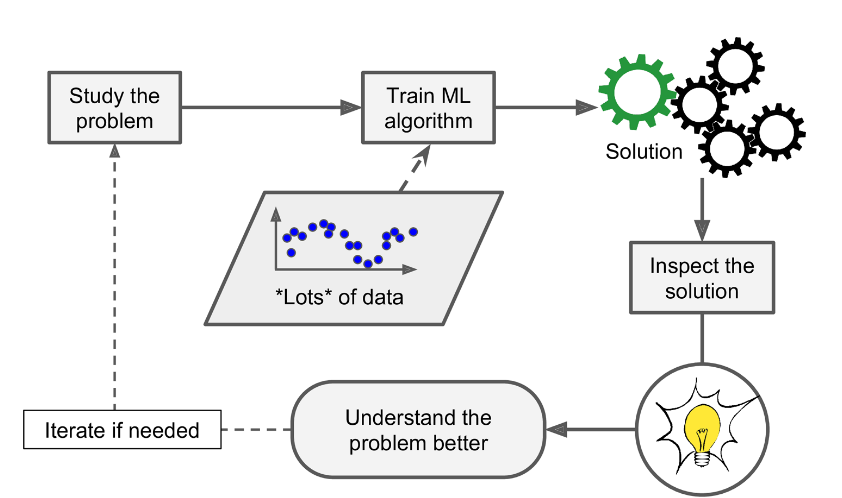

*Imagem retirada do livro Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 2nd Edition*


### Parte 1 - Exportando a Base de Dados e Estudo sobre o Problema

A primeira parte se concentra a exportação da base de dados e o estudo do problema, onde o objetivo e entender os registros e atributos que formam a base de dados

In [12]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt 

try:
    df = pd.read_csv('koi_data.csv')
    linhas , colunas = df.shape
    colunas_nome = df.columns
    print(f"Quantidade de linhas: {linhas} e colunas: {colunas}")
    print(f"Nomes das Colunas: {colunas_nome.values}")
except Exception as e:
    print(f'Base de Dados não encontrada {e}')



Quantidade de linhas: 5202 e colunas: 43
Nomes das Colunas: ['kepoi_name' 'koi_disposition' 'koi_period' 'koi_impact' 'koi_duration'
 'koi_depth' 'koi_ror' 'koi_srho' 'koi_prad' 'koi_sma' 'koi_incl'
 'koi_teq' 'koi_insol' 'koi_dor' 'koi_max_sngle_ev' 'koi_max_mult_ev'
 'koi_model_snr' 'koi_steff' 'koi_slogg' 'koi_smet' 'koi_srad' 'koi_smass'
 'koi_kepmag' 'koi_gmag' 'koi_rmag' 'koi_imag' 'koi_zmag' 'koi_jmag'
 'koi_hmag' 'koi_kmag' 'koi_fwm_stat_sig' 'koi_fwm_sra' 'koi_fwm_sdec'
 'koi_fwm_srao' 'koi_fwm_sdeco' 'koi_fwm_prao' 'koi_fwm_pdeco'
 'koi_dicco_mra' 'koi_dicco_mdec' 'koi_dicco_msky' 'koi_dikco_mra'
 'koi_dikco_mdec' 'koi_dikco_msky']


In [13]:
df.head(5)

,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.450,24.090,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5202 entries, 0 to 5201
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepoi_name        5202 non-null   object 
 1   koi_disposition   5202 non-null   object 
 2   koi_period        5202 non-null   float64
 3   koi_impact        5202 non-null   float64
 4   koi_duration      5202 non-null   float64
 5   koi_depth         5202 non-null   float64
 6   koi_ror           5202 non-null   float64
 7   koi_srho          5202 non-null   float64
 8   koi_prad          5202 non-null   float64
 9   koi_sma           5202 non-null   float64
 10  koi_incl          5202 non-null   float64
 11  koi_teq           5202 non-null   float64
 12  koi_insol         5202 non-null   float64
 13  koi_dor           5202 non-null   float64
 14  koi_max_sngle_ev  5202 non-null   float64
 15  koi_max_mult_ev   5202 non-null   float64
 16  koi_model_snr     5202 non-null   float64


In [15]:
df.describe()

,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,koi_incl,koi_teq,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
count,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,...,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000
mean,37.032237,0.717106,5.607025,21340.318993,0.235205,3.415370,112.230798,0.158146,81.181413,1143.721069,...,-0.355681,-0.805629,-0.000263,0.000439,-0.049743,-0.087413,1.930251,-0.038402,-0.098738,1.920226
std,88.417985,2.628207,6.962634,66989.808550,2.586213,25.131368,3699.799318,0.241792,16.308839,775.788868,...,10.978677,14.741473,0.065707,0.077519,2.465670,2.746534,3.147553,2.465094,2.734732,3.142764
min,0.306940,0.000000,0.104600,0.800000,0.001290,0.000040,0.080000,0.007200,2.290000,92.000000,...,-275.600000,-397.620000,-4.000000,-0.800000,-21.500000,-75.900000,0.000000,-23.600000,-76.600000,0.000000
25%,2.213963,0.226000,2.500250,176.800000,0.013057,0.176092,1.460000,0.033000,81.930000,615.250000,...,-0.500000,-0.570000,-0.000240,-0.000240,-0.270000,-0.291500,0.128250,-0.265250,-0.320000,0.180000
50%,7.386755,0.610000,3.805500,495.950000,0.024185,0.748045,2.600000,0.073650,87.890000,948.000000,...,0.000000,-0.030000,0.000000,0.000000,0.000000,0.000000,0.460000,-0.007000,-0.018000,0.453000
75%,23.448118,0.923750,6.000750,2120.525000,0.171260,2.267062,21.645000,0.158200,89.520000,1482.000000,...,0.500000,0.450000,0.000260,0.000280,0.230000,0.230000,2.570000,0.226250,0.250000,2.420000
max,1071.232620,100.806000,138.540000,864260.000000,99.870650,918.752390,200346.000000,2.034500,90.000000,9791.000000,...,97.780000,98.780000,1.190000,5.000000,45.680000,27.500000,88.600000,46.570000,31.200000,89.600000


In [16]:
print(df['koi_disposition'].value_counts())
df_false_positive = df[df['koi_disposition'] == 'FALSE POSITIVE']
df_confirmed = df[df['koi_disposition'] == 'CONFIRMED']

koi_disposition
FALSE POSITIVE    3098
CONFIRMED         2104
Name: count, dtype: int64


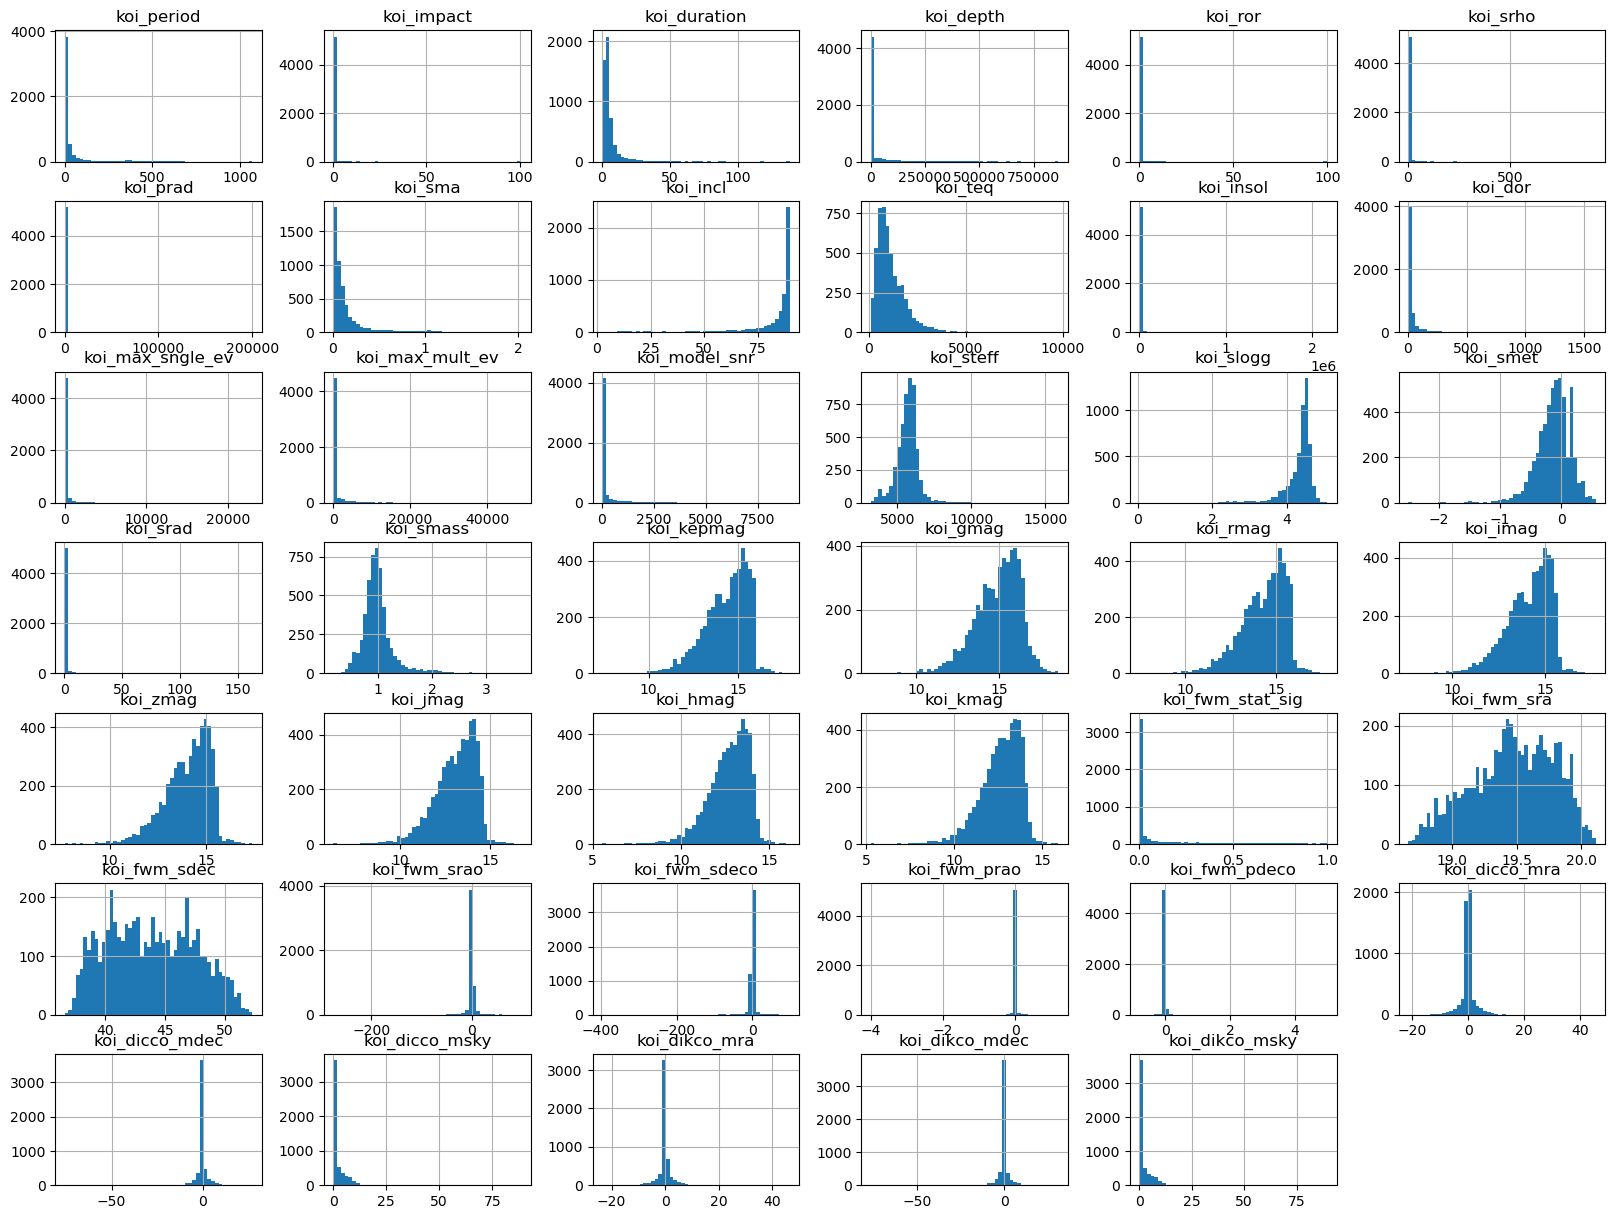

In [17]:
%matplotlib inline
df.hist(bins  = 50, figsize=(20,15))
plt.show()

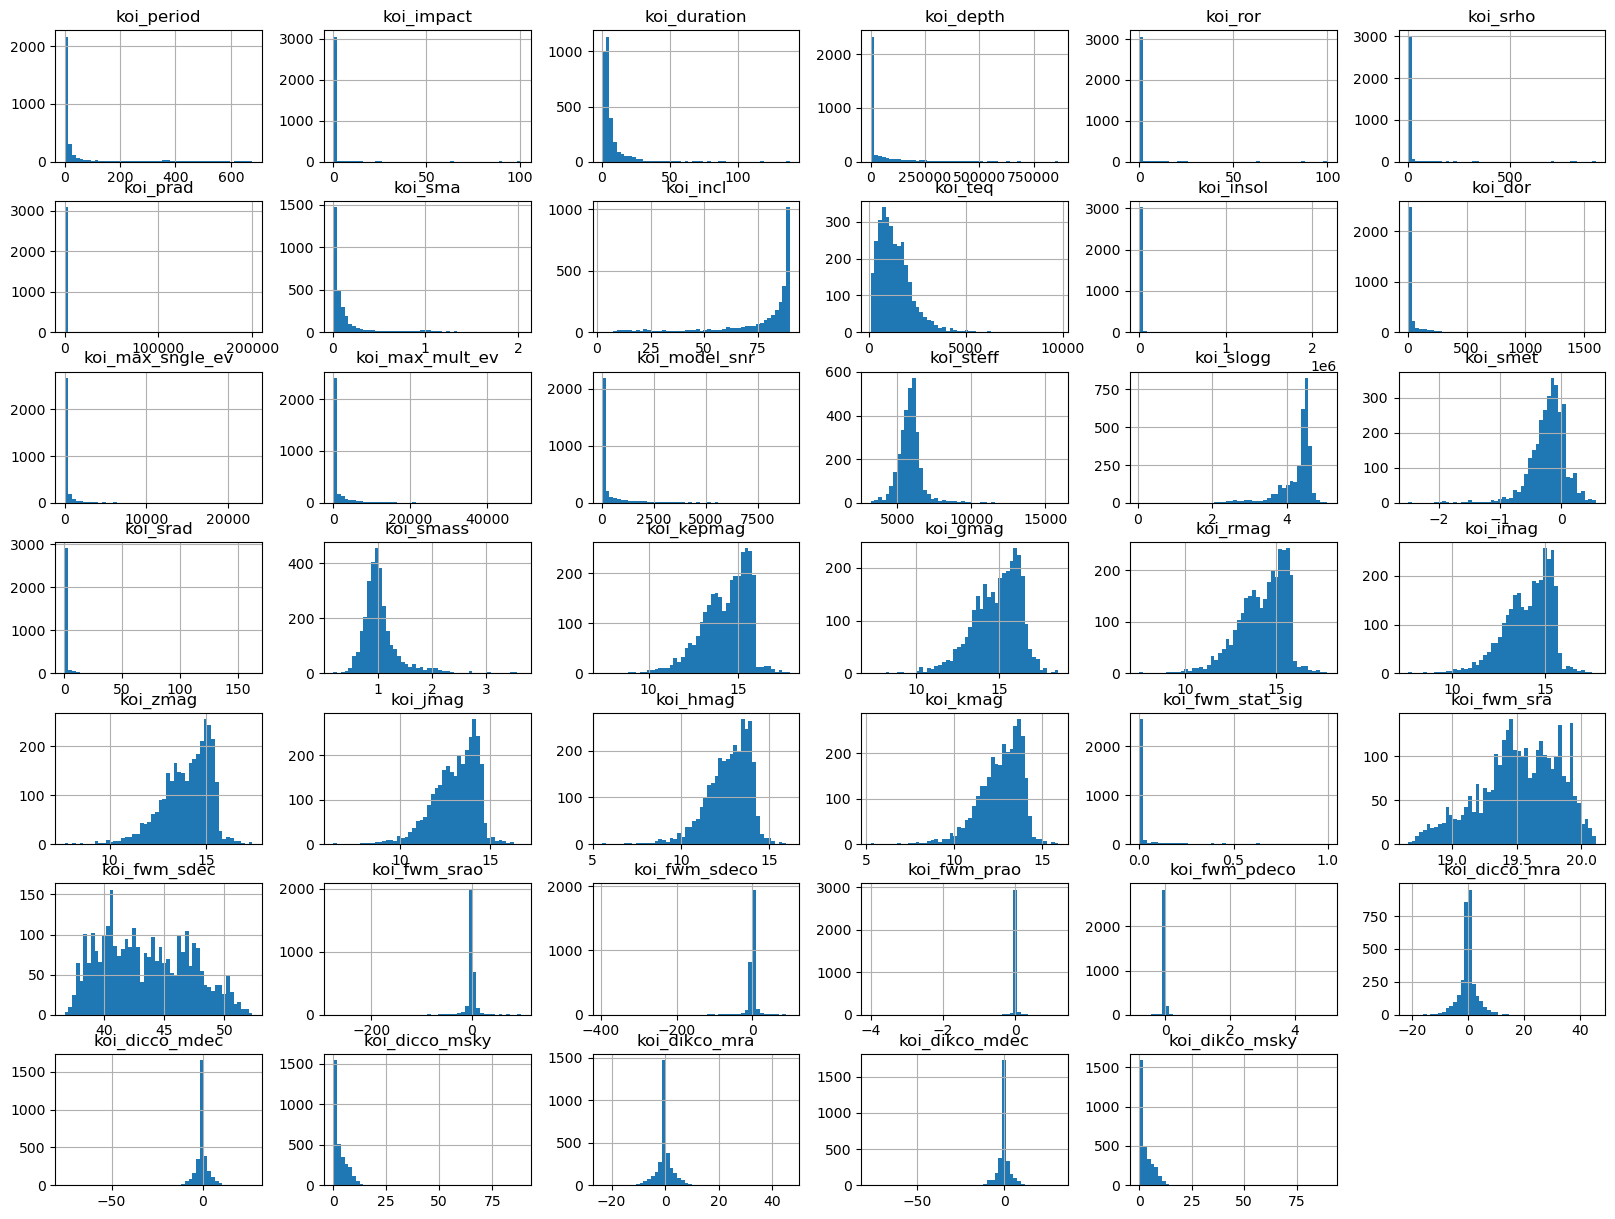

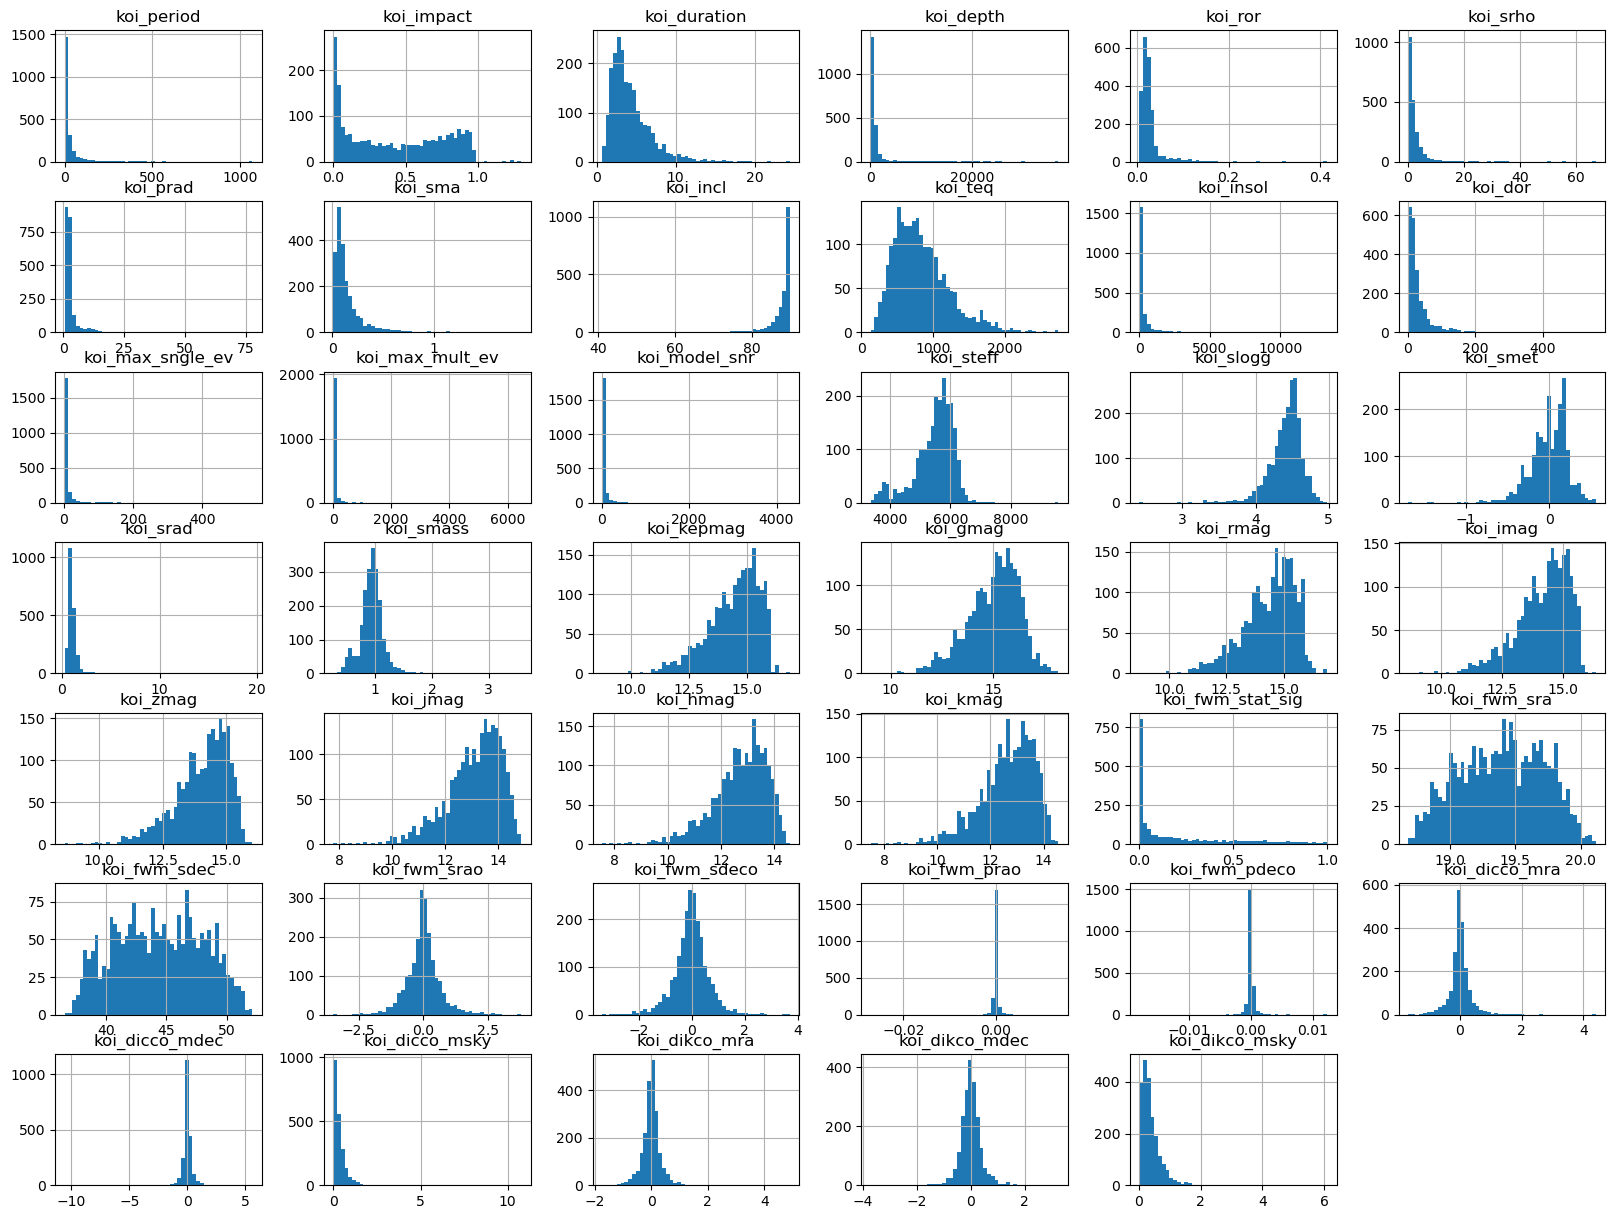

In [18]:
%matplotlib inline
df_false_positive.hist(bins  = 50, figsize=(20,15))
df_confirmed.hist(bins  = 50, figsize=(20,15))

plt.show()

### 2- Normalização de Dados 

Para ter um melhor aproveitamento do modelo precisamos normalizar os dados 

Foi utilizado o metodo StandardScaler da biblioteca sklearn do modulo preprocessing 
Ele transforma os dados para que tenham média zero  e desvio padrão unitário, centrando os dados e colocando-os na mesma escala, o que é crucial para algoritmos sensíveis à magnitude dos valores


In [19]:
from sklearn.preprocessing import StandardScaler
X = df.copy()
Y = X[['koi_disposition']]
X.drop(columns=['kepoi_name', 'koi_disposition'] , inplace=True)
scaler = StandardScaler()
scaler.fit(X)
colunas = X.columns
X = pd.DataFrame(scaler.transform(X),columns=colunas)
X.head()



,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,koi_incl,koi_teq,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,-0.311553,-0.217320,-0.380571,-0.309398,-0.082315,-0.008254,-0.029726,-0.301305,0.519927,-0.452127,...,0.071571,0.118428,0.000962,-0.012756,0.016120,0.104656,-0.549766,0.048036,0.149476,-0.509227
1,0.196655,-0.049889,-0.158005,-0.305531,-0.080146,-0.015587,-0.029572,0.476709,0.514408,-0.903324,...,-0.024989,0.138102,0.014051,-0.019207,0.178363,0.031830,-0.489396,0.214374,0.079993,-0.451947
2,-0.399225,0.212673,-0.459729,-0.197976,0.058850,-0.127127,-0.021293,-0.543685,-0.864118,0.323932,...,0.022289,0.054791,0.049972,-0.023980,-0.080820,0.085357,-0.521487,-0.088686,0.072313,-0.523229
3,-0.390305,-0.006129,-0.567731,-0.309585,-0.081650,-0.056867,-0.029594,-0.499428,0.259307,0.338113,...,0.031490,0.070260,0.005224,-0.006563,0.032344,-0.000942,-0.581540,0.043979,0.043423,-0.588782
4,-0.335603,0.171957,-0.084032,-0.315102,-0.020037,-0.135721,-0.019738,-0.314955,-1.242477,0.255608,...,-1.192819,1.688978,0.050124,-0.077263,-1.807495,2.839274,2.224084,-1.825095,2.856766,2.236391


### 3. Aplicação de Modelos

In [20]:

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, learning_curve ,KFold, LearningCurveDisplay, ShuffleSplit
from sklearn.metrics import confusion_matrix , accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

X_train, X_test , y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=41)
kf = KFold(n_splits=5, shuffle=True, random_state=41)


target_name = ["Confirmado" , "Falso Positivo"]

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

def print_cross_validate(score):
    print(" Cross Validação ")
    print("Acurácia média :", np.mean(score['test_accuracy']))
    print("Precisão média :", np.mean(score['test_precision']))
    print("Recall média :", np.mean(score['test_recall']))
    print("F1-score média :", np.mean(score['test_f1']))    

def print_classification_report(y_test, y_pred):
    print(classification_report(y_test, y_pred, target_names=target_name))

def plot_matrix(y_test, y_pred):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title("Matriz de Confusao Teste")
    plt.show()

def plot_curve(model):
    fig, ax = plt.subplots( figsize=(10, 6), sharey=True)
    common_params = {
        "X": X,
        "y": Y,
        "train_sizes": np.linspace(0.1, 1.0, 5),
        "cv": kf,
        "scoring": "f1_macro",
        "n_jobs": -1,
        "line_kw": {"marker": "o"},
        "std_display_style": "fill_between",
    }
    LearningCurveDisplay.from_estimator(model, **common_params, ax=ax)
    ax.set_title(f"Curva de Aprendizagem - {model.__class__.__name__}")
    ax.set_xlabel("Tamanho do treino")
    ax.set_ylabel("F1-score")
    ax.grid()
    plt.show()

def plot_features_importece(clf):
    imp = clf.feature_importances_
    order = np.argsort(imp)[::1]
    plt.barh(np.array(X.columns)[order][::1], imp[order][::1])
    plt.title("Importância das Features")
    plt.tight_layout()
    plt.show()

 Cross Validação 
Acurácia média : 0.9161852508682481
Precisão média : 0.9115877370005115
Recall média : 0.9252817497305184
F1-score média : 0.9147394344691525
                precision    recall  f1-score   support

    Confirmado       0.85      0.98      0.91       427
Falso Positivo       0.98      0.88      0.93       614

      accuracy                           0.92      1041
     macro avg       0.92      0.93      0.92      1041
  weighted avg       0.93      0.92      0.92      1041

Acurácia Treino: 0.912761355443403


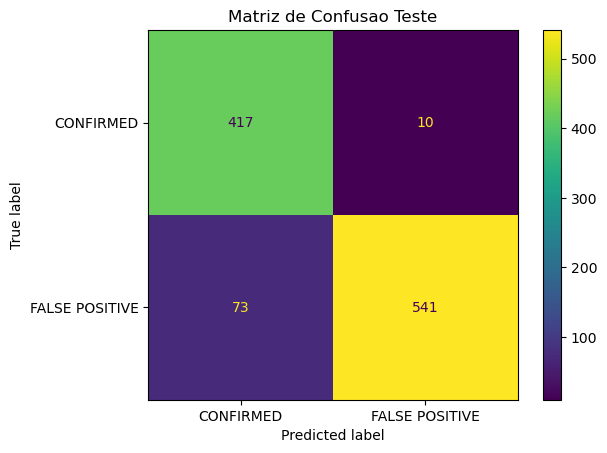

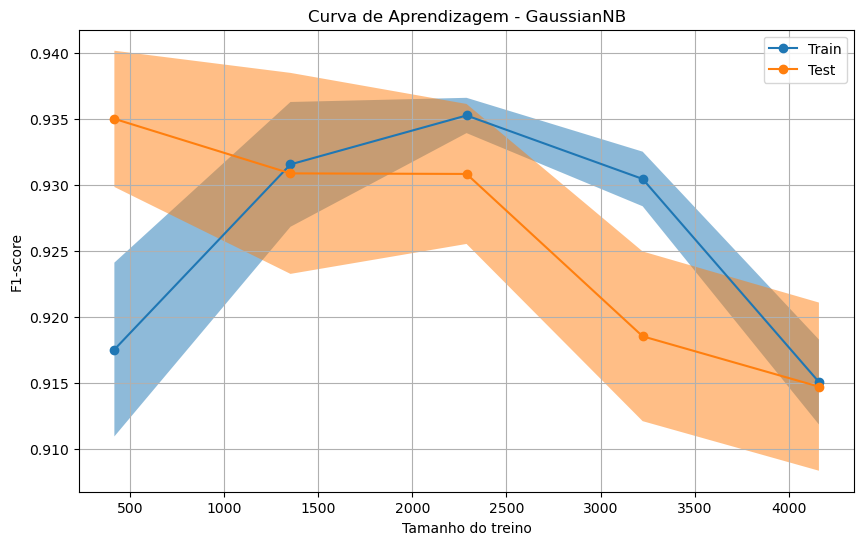

In [21]:
from sklearn.naive_bayes import GaussianNB


clf  = GaussianNB()

score = cross_validate(clf,X, Y, cv=kf,scoring=scoring)

print_cross_validate(score)


clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


print_classification_report(y_test, y_pred)
print(f"Acurácia Treino: {clf.score(X_train, y_train)}")
plot_matrix(y_test, y_pred)
plot_curve(clf)

 Cross Validação 
Acurácia média : 0.9488648119411808
Precisão média : 0.944972206554934
Recall média : 0.950005036585804
F1-score média : 0.9472025309989156
                precision    recall  f1-score   support

    Confirmado       0.94      0.96      0.95       427
Falso Positivo       0.97      0.96      0.96       614

      accuracy                           0.96      1041
     macro avg       0.95      0.96      0.96      1041
  weighted avg       0.96      0.96      0.96      1041

Acurácia Treino: 0.9634703196347032


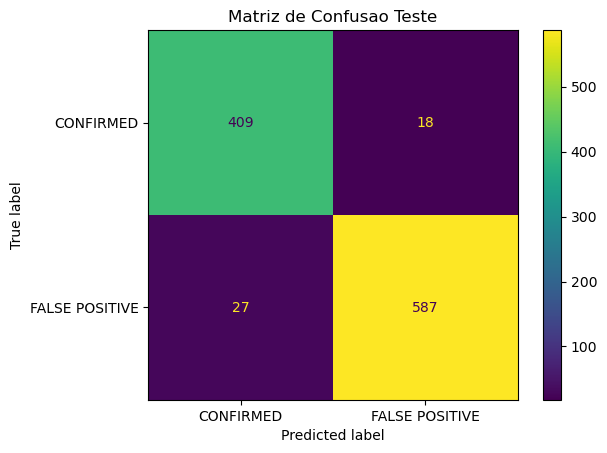

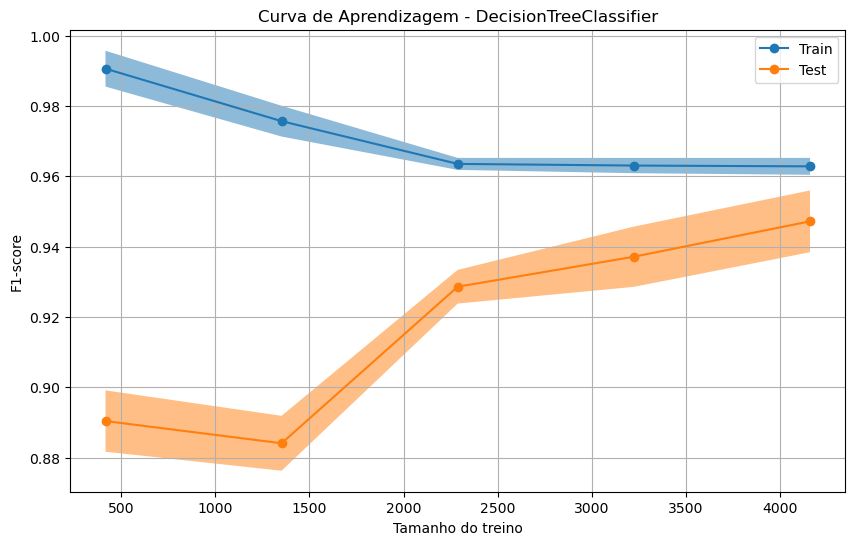

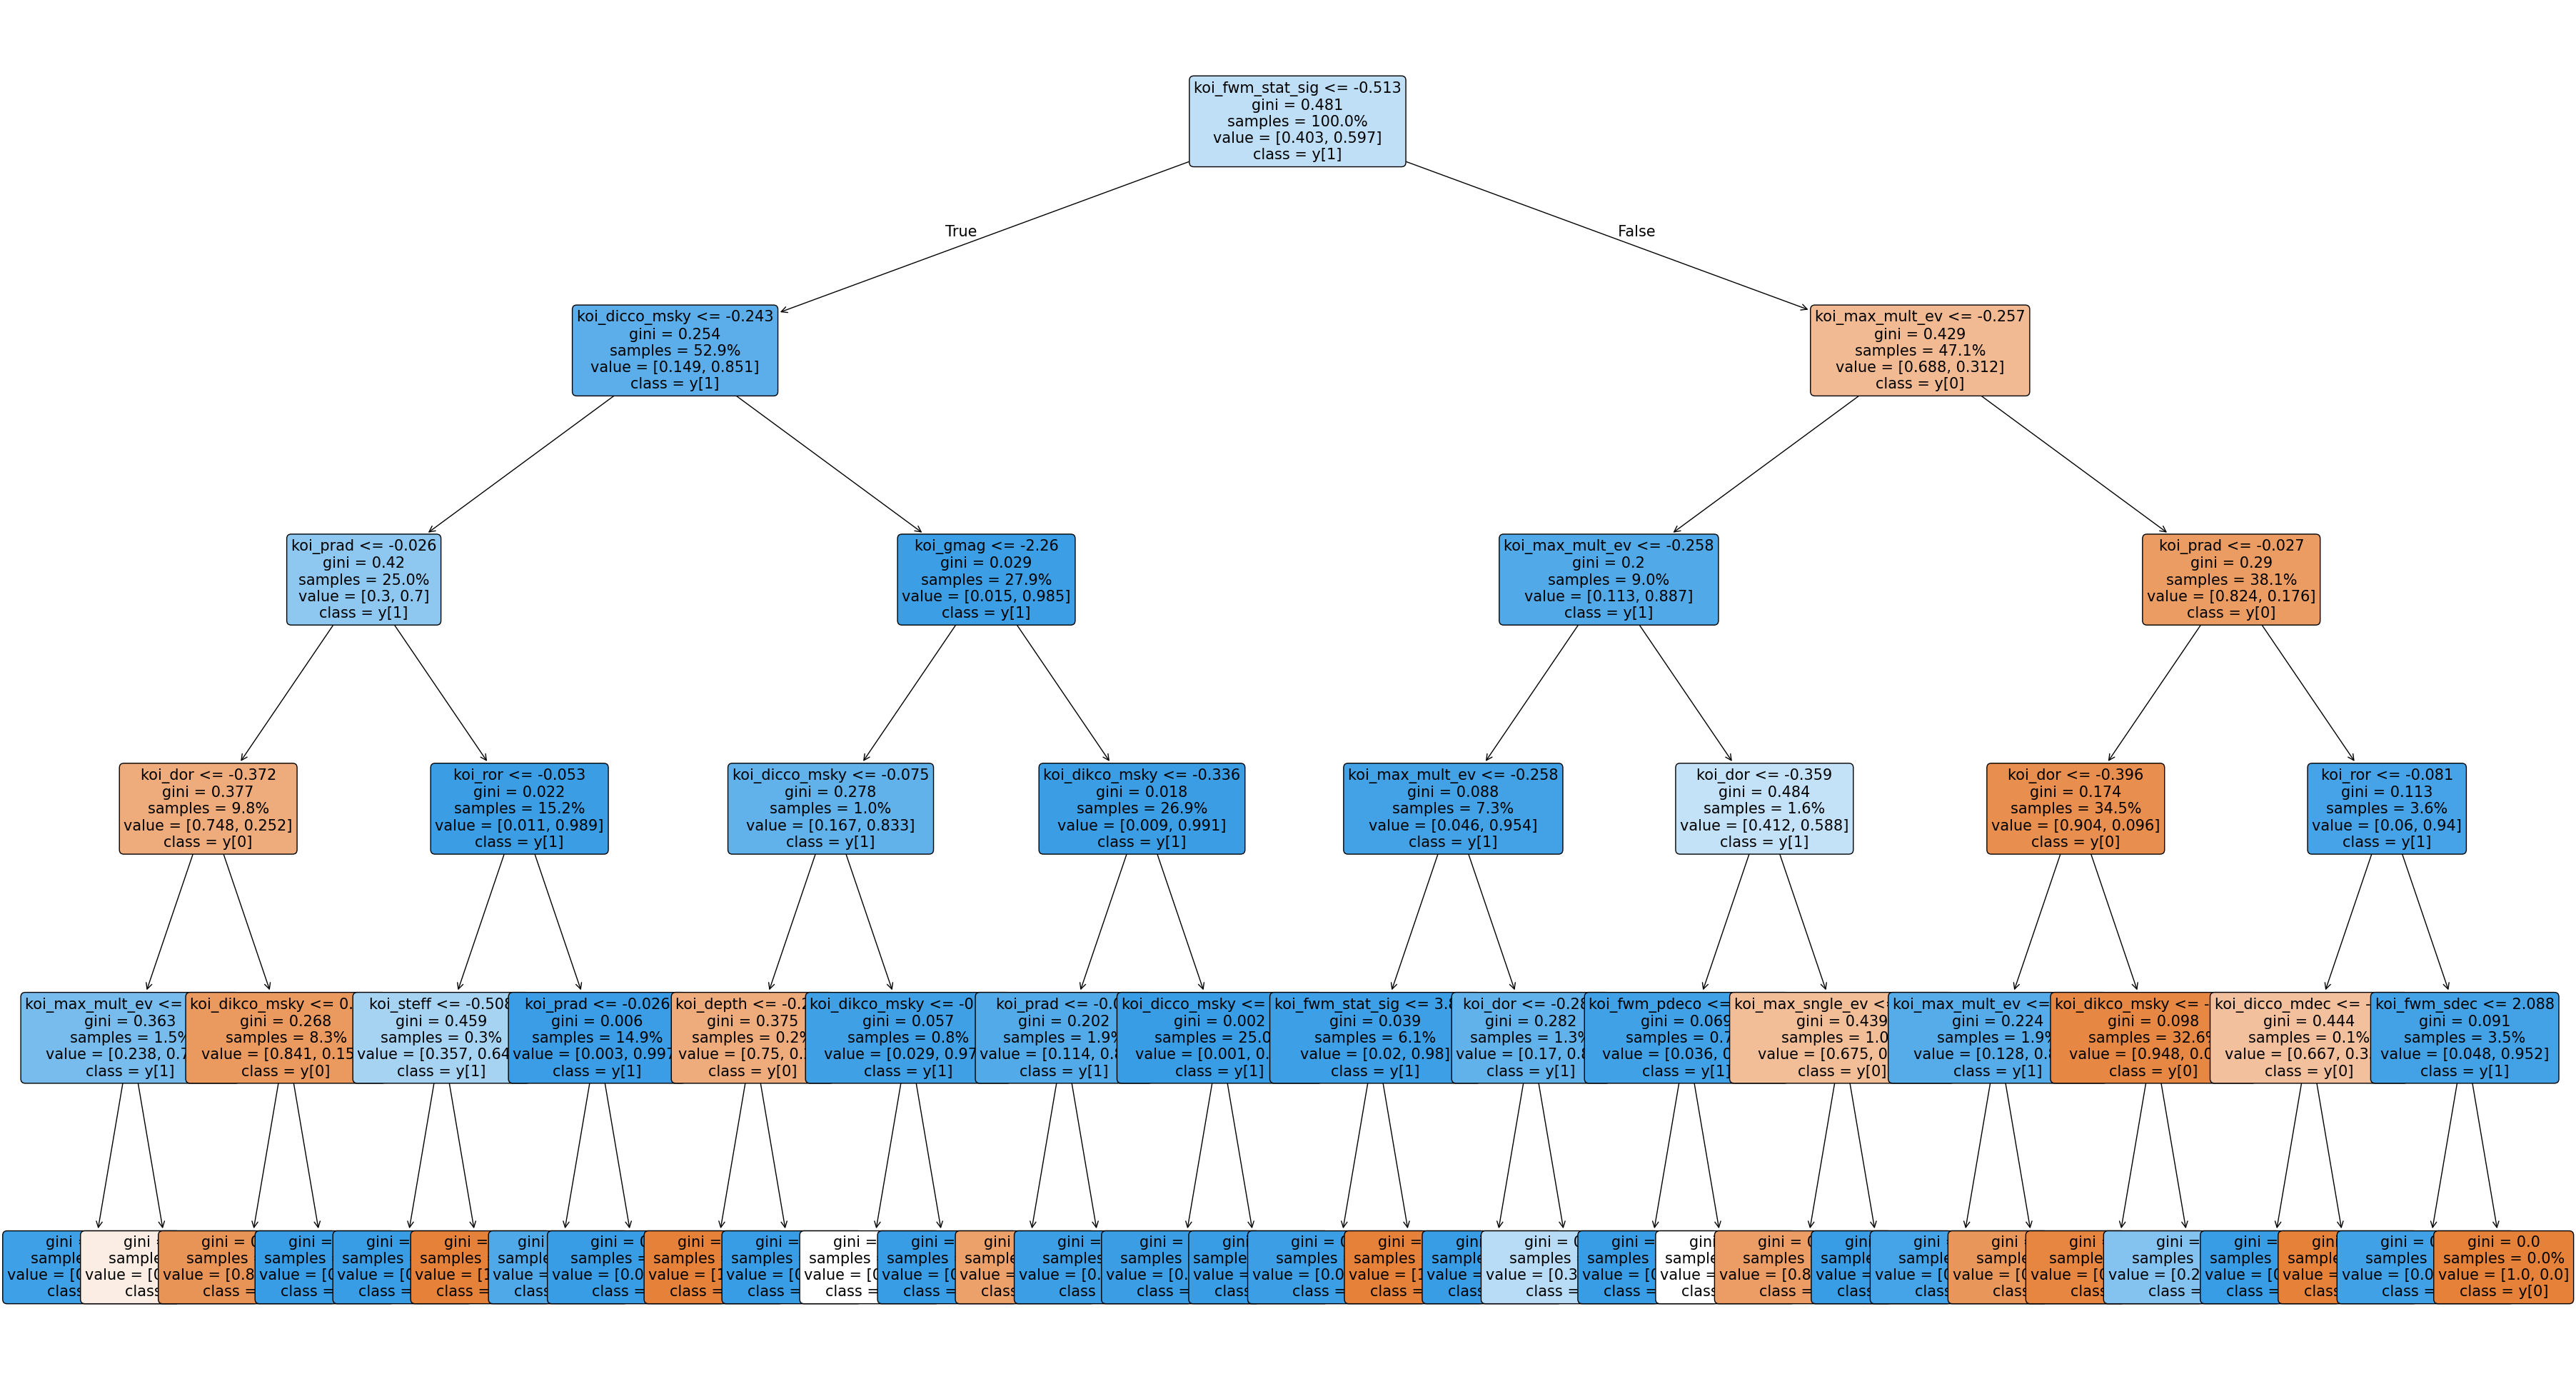

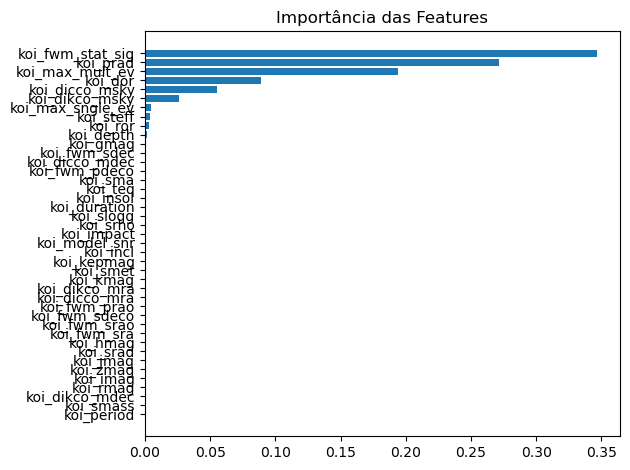

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
clf = DecisionTreeClassifier(random_state= 41, max_depth=5)

score = cross_validate(clf,X, Y, cv=kf,scoring=scoring)

print_cross_validate(score)


clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


print_classification_report(y_test, y_pred)
print(f"Acurácia Treino: {clf.score(X_train, y_train)}")
plot_matrix(y_test, y_pred)
plot_curve(clf)

plt.figure(figsize=(45,25))

tree.plot_tree(clf, proportion=True, fontsize=15, feature_names=X.columns , filled=True, class_names=True,  rounded=True)

plt.show()
plot_features_importece(clf)